In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/amlfraud/PS_20174392719_1491204439457_log.csv


In [3]:
!pip install matplotlib seaborn scikit-learn xgboost

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import ndcg_score
import xgboost as xgb

In [5]:
file_path = "/kaggle/input/amlfraud/PS_20174392719_1491204439457_log.csv"
df=pd.read_csv(file_path)

In [6]:
print(df.head())

   step      type    amount     nameOrig  oldbalanceOrg  newbalanceOrig  \
0     1   PAYMENT   9839.64  C1231006815       170136.0       160296.36   
1     1   PAYMENT   1864.28  C1666544295        21249.0        19384.72   
2     1  TRANSFER    181.00  C1305486145          181.0            0.00   
3     1  CASH_OUT    181.00   C840083671          181.0            0.00   
4     1   PAYMENT  11668.14  C2048537720        41554.0        29885.86   

      nameDest  oldbalanceDest  newbalanceDest  isFraud  isFlaggedFraud  
0  M1979787155             0.0             0.0        0               0  
1  M2044282225             0.0             0.0        0               0  
2   C553264065             0.0             0.0        1               0  
3    C38997010         21182.0             0.0        1               0  
4  M1230701703             0.0             0.0        0               0  


In [7]:
df['isFraud'].mean() #fraud rate-0.1%

np.float64(0.001290820448180152)

In [8]:
df['amount'].describe()

count    6.362620e+06
mean     1.798619e+05
std      6.038582e+05
min      0.000000e+00
25%      1.338957e+04
50%      7.487194e+04
75%      2.087215e+05
max      9.244552e+07
Name: amount, dtype: float64

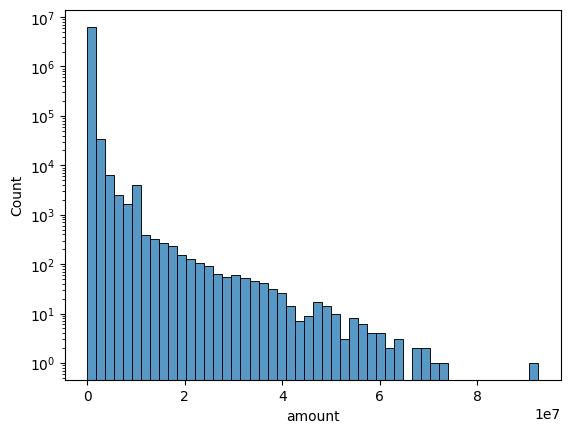

In [9]:
sns.histplot(df['amount'], bins=50)
plt.yscale('log')

In [10]:
pd.crosstab(df['type'], df['isFraud'], normalize='index')

isFraud,0,1
type,,
CASH_IN,1.000000,0.000000
CASH_OUT,0.998160,0.001840
DEBIT,1.000000,0.000000
PAYMENT,1.000000,0.000000
TRANSFER,0.992312,0.007688


In [11]:
df['is_high_risk_type']=df['type'].isin(['TRANSFER','CASH_OUT']).astype(int)
df['origin_balance_ratio']=(df['oldbalanceOrg'] - df['newbalanceOrig']) / (df['oldbalanceOrg'] + 1)
df['zero_balance_after']=(df['newbalanceOrig'] == 0).astype(int)

df['aml_alert'] = (
    (df['amount'] > 200000) |
    (df['is_high_risk_type'] == 1) |
    (df['origin_balance_ratio'] > 0.9) |
    (df['zero_balance_after'] == 1)
).astype(int)

print("AML alert rate:", df['aml_alert'].mean())


AML alert rate: 0.6883565260851662


In [12]:
alerts=df[df['aml_alert']==1].copy()
print("Fraud rate inside AML alerts:", alerts['isFraud'].mean())

Fraud rate inside AML alerts: 0.001875220760266965


In [21]:
alerts = df[
    (df['amount'] > 2000) | 
    (df['type'].isin(['CASH_OUT','TRANSFER']))
].copy()



In [22]:
alerts = alerts.sort_values(['nameOrig','step']).reset_index(drop=True)

In [31]:
alerts['txns_5']  = alerts.groupby('nameOrig')['amount'].rolling(5, min_periods=1).count().reset_index(0,drop=True)
alerts['txns_10'] = alerts.groupby('nameOrig')['amount'].rolling(10, min_periods=1).count().reset_index(0,drop=True)

alerts['amt_5']  = alerts.groupby('nameOrig')['amount'].rolling(5, min_periods=1).sum().reset_index(0,drop=True)
alerts['amt_10'] = alerts.groupby('nameOrig')['amount'].rolling(10, min_periods=1).sum().reset_index(0,drop=True)

alerts['max_10'] = alerts.groupby('nameOrig')['amount'].rolling(10, min_periods=1).max().reset_index(0,drop=True)


In [32]:
from collections import deque

def fast_unique(series, window=20):
    q = deque()
    count = {}
    out = []

    for v in series:
        q.append(v)
        count[v] = count.get(v,0)+1

        if len(q) > window:
            old = q.popleft()
            count[old] -= 1
            if count[old] == 0:
                del count[old]

        out.append(len(count))

    return out


alerts['unique_receivers'] = (
    alerts.groupby('nameOrig')['nameDest']
    .apply(lambda x: pd.Series(fast_unique(x,10), index=x.index))
    .reset_index(level=0,drop=True)
)


In [33]:
def safe_norm(x):
    m = x.max()
    return x/m if m > 0 else 0

alerts['txns_norm'] = safe_norm(alerts['txns_10'])
alerts['amt_norm']  = safe_norm(alerts['amt_10'])
alerts['max_norm']  = safe_norm(alerts['max_10'])
alerts['net_norm']  = safe_norm(alerts['unique_receivers'])


In [34]:
#alerts[['txns_20','amt_20','max_20','unique_receivers']].describe()
alerts['risk_score'] = (
    0.30 * alerts['txns_norm'] +
    0.35 * alerts['amt_norm']  +
    0.20 * alerts['net_norm']  +
    0.15 * alerts['max_norm']
)


In [35]:
alerts['risk_label'] = pd.qcut(alerts['risk_score'],3,labels=['Low','Medium','High'])



In [36]:
features = [
    'txns_5','txns_10',
    'amt_5','amt_10',
    'max_10',
    'unique_receivers'
]

X = alerts[features]
y = alerts['risk_score']     

In [37]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [38]:
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train, y_train)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=None, num_parallel_tree=None, ...)

In [39]:
alerts['predicted_risk'] = model.predict(alerts[features])
queue = alerts.sort_values('predicted_risk', ascending=False)


In [41]:
y_true = alerts['risk_score']
y_pred = alerts['predicted_risk']


In [42]:
from sklearn.metrics import ndcg_score

ndcg_10 = ndcg_score([y_true], [y_pred], k=10)
ndcg_50 = ndcg_score([y_true], [y_pred], k=50)

print("NDCG@10:", round(ndcg_10,4))
print("NDCG@50:", round(ndcg_50,4))


NDCG@10: 0.8726
NDCG@50: 0.8303


In [43]:
queue[['nameOrig','amount','predicted_risk','isFraud']].head(20)


,nameOrig,amount,predicted_risk,isFraud
2469607,C1784010646,51324.77,0.502074,0
5223114,C724452879,189157.17,0.502074,0
3075905,C1976208114,162120.24,0.502074,0
2842737,C1902386530,246956.95,0.502074,0
1671011,C1530544995,2491.87,0.502042,0
3461370,C2098525306,49605.55,0.502011,0
2134827,C1677795071,8285.71,0.501517,0
3149473,C1999539787,28653.25,0.501517,0
2622675,C1832548028,13377.05,0.501517,0
4200509,C400299098,120008.43,0.500931,0


In [51]:
import networkx as nx

G = nx.from_pandas_edgelist(
    alerts,
    source='nameOrig',
    target='nameDest',
    edge_attr='amount',
    create_using=nx.DiGraph()
)


In [52]:
degree = dict(G.degree())
suspicious_nodes = sorted(degree.items(), key=lambda x: x[1], reverse=True)[:10]
suspicious_nodes


[('C1286084959', 113),
 ('C985934102', 108),
 ('C665576141', 105),
 ('C2083562754', 101),
 ('C248609774', 101),
 ('C1590550415', 101),
 ('C1789550256', 99),
 ('C451111351', 99),
 ('C1360767589', 98),
 ('C1023714065', 97)]

In [59]:
import networkx as nx

In [60]:
G = nx.from_pandas_edgelist(
    alerts,
    source='nameOrig',
    target='nameDest',
    edge_attr='amount',
    create_using=nx.DiGraph()
)

In [62]:
degree = dict(G.degree())
suspicious_nodes = sorted(degree.items(), key=lambda x: x[1], reverse=True)[:10]
top_account = suspicious_nodes[0][0]

In [63]:
neighbors = list(G.neighbors(top_account))
sub_nodes = [top_account] + neighbors
subG = G.subgraph(sub_nodes)

In [64]:
plt.figure(figsize=(12, 12))

<Figure size 1200x1200 with 0 Axes>

<Figure size 1200x1200 with 0 Axes>

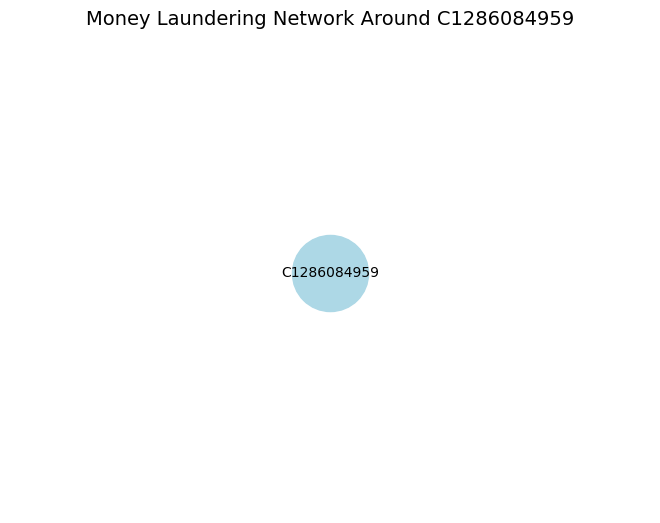

In [65]:
pos = nx.spring_layout(subG, k=0.5, seed=42) 

nx.draw(
    subG,
    pos,
    with_labels=True,
    node_color='lightblue',
    node_size=3000,
    edge_color='gray',
    font_size=10,
    arrows=True,
    arrowsize=20
)

plt.title(f"Money Laundering Network Around {top_account}", fontsize=14)
plt.show()